# This is an Exploratory Data Analysis (EDA) using python in colab

First, we need the "Big Three" of Python data science:

*   Matplotlib/Seaborn: For turning boring numbers into pretty, insightful pictures.

*   Pandas: For data manipulation (the bread and butter).

*   NumPy: For the heavy lifting on math.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make those plots look a bit more sophisticated
sns.set_theme(style="whitegrid")

In [5]:
df=pd.read_csv("/content/drive/MyDrive/Mydata/customer_shopping_data.csv")

In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB
None
                age      quantity         price
count  99457.000000  99457.000000  99457.000000
mean      43.427089      3.003429    689.256321
std       14.990054      1.413025    941.184567
min       18.000000      1.000000      5.230000
25%       30.000000      2.000000     45.450

Looking at the data distribution and disparity in prices, it is evident that the data is right skewed.

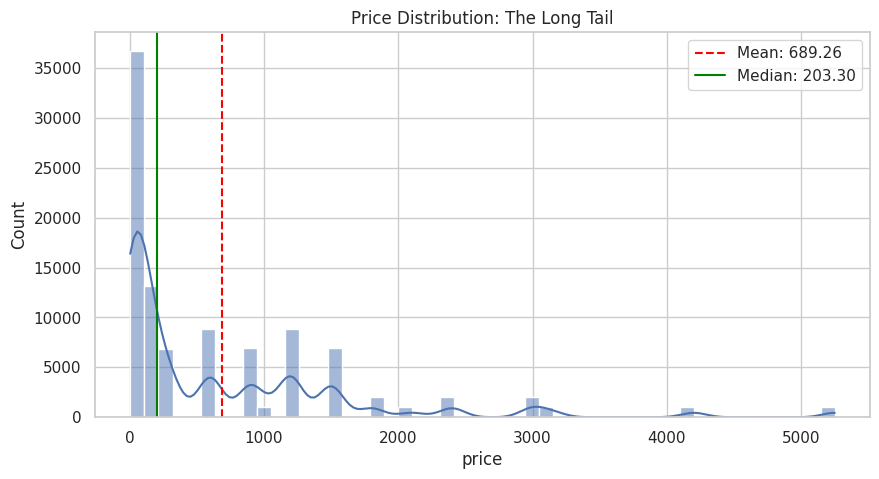

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: {df["price"].mean():.2f}')
plt.axvline(df['price'].median(), color='green', linestyle='-', label=f'Median: {df["price"].median():.2f}')
plt.title('Price Distribution: The Long Tail')
plt.legend()
plt.show()

In [8]:
print(df.columns)

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')


#As we can see these are the headers of the data, and we have to do our analysis using these headers.

# Task 1
Calculate the total sales by age and gender from the `df` DataFrame, and then create a line chart showing total sales against age, with separate lines for each gender.

## Calculate Total Sales by Age and Gender

### Subtask:
Group the DataFrame by 'age' and 'gender' and sum the 'price' to get the total sales for each age and gender combination.


**Reasoning**:
To calculate total sales by age and gender, I will group the DataFrame `df` by 'age' and 'gender' columns and then sum the 'price' for each group, storing the result in `sales_by_age_gender`.



In [9]:
sales_by_age_gender = df.groupby(['age', 'gender'])['price'].sum().reset_index()
print("Total sales by age and gender:")
print(sales_by_age_gender.head())

Total sales by age and gender:
   age  gender      price
0   18  Female  720800.22
1   18    Male  490663.40
2   19  Female  777906.39
3   19    Male  517250.08
4   20  Female  730643.58


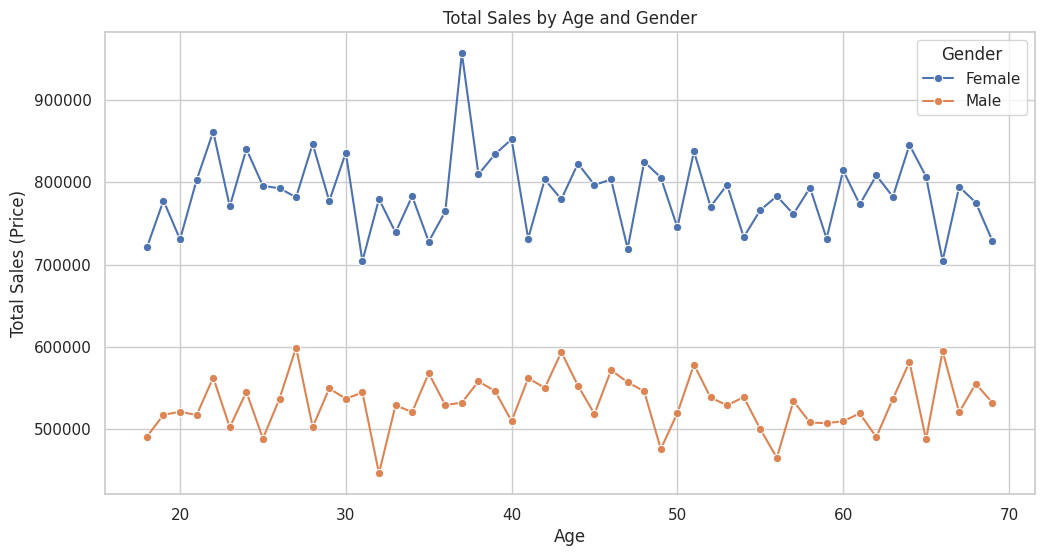

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_by_age_gender, x='age', y='price', hue='gender', marker='o')
plt.title('Total Sales by Age and Gender')
plt.xlabel('Age')
plt.ylabel('Total Sales (Price)')
plt.grid(True)
plt.legend(title='Gender')
plt.show()

## Summary:

### Data Analysis Key Findings
*   Total sales were successfully calculated by grouping the data by 'age' and 'gender' and summing the 'price' for each group.
*   A new DataFrame, `sales_by_age_gender`, was created, containing the aggregated total sales for each age and gender combination.
*   For individuals aged 18, the total sales for females were reported as 720800.22, while for males, the total sales were 490663.40.




# Task 1
Identify the most frequently used `payment_method` from the `df` DataFrame, and then analyze the age distribution for customers who use this specific payment method.

## Identify Most Used Payment Method

### Subtask:
Calculate the frequency of each payment method and determine the most popular one.


**Reasoning**:
To identify the most popular payment method, I will use the `value_counts()` method on the 'payment_method' column to get the frequency of each method and then `idxmax()` to find the one with the highest count.



In [11]:
payment_method_counts = df['payment_method'].value_counts()
most_frequent_payment_method = payment_method_counts.idxmax()

print("Frequency of each payment method:")
print(payment_method_counts)
print(f"\nThe most frequent payment method is: {most_frequent_payment_method}")

Frequency of each payment method:
payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64

The most frequent payment method is: Cash


## Analyze Age Distribution for the Most Used Payment Method

### Subtask:
Filter the DataFrame to include only transactions made with the most frequent payment method, and then examine the age distribution of these customers.


**Reasoning**:
To analyze the age distribution for customers using the most frequent payment method, I need to first filter the original DataFrame `df` to include only those transactions where the 'payment_method' matches `most_frequent_payment_method`.



In [12]:
df_most_frequent_payment = df[df['payment_method'] == most_frequent_payment_method]
print(f"DataFrame filtered for '{most_frequent_payment_method}' payment method. First 5 rows:")
print(df_most_frequent_payment.head())

DataFrame filtered for 'Cash' payment method. First 5 rows:
   invoice_no customer_id  gender  age         category  quantity   price  \
2     I127801     C266599    Male   20         Clothing         1  300.08   
4     I337046     C189076  Female   53            Books         4   60.60   
6     I121056     C151197  Female   49        Cosmetics         1   40.66   
10    I306368     C240286  Female   36  Food & Beverage         2   10.46   
13    I179802     C312861    Male   25         Clothing         2  600.16   

   payment_method invoice_date shopping_mall  
2            Cash    9/11/2021     Metrocity  
4            Cash   24/10/2021        Kanyon  
6            Cash   13/03/2022  Istinye Park  
10           Cash   25/12/2022     Metrocity  
13           Cash   17/11/2022   Cevahir AVM  


**Reasoning**:
To understand the age distribution for customers using the most frequent payment method, a histogram is an appropriate visualization. Additionally, descriptive statistics for the 'age' column will provide further insight into the central tendency and spread of ages.



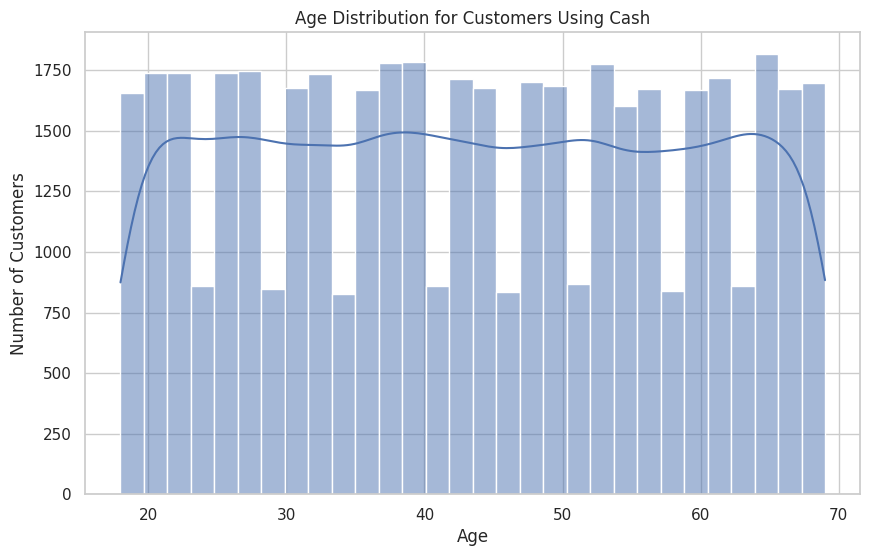


Descriptive statistics for age of customers using Cash payment method:
count    44447.000000
mean        43.457421
std         15.011227
min         18.000000
25%         30.000000
50%         43.000000
75%         56.000000
max         69.000000
Name: age, dtype: float64


In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df_most_frequent_payment['age'], bins=30, kde=True)
plt.title(f'Age Distribution for Customers Using {most_frequent_payment_method}')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()

print(f"\nDescriptive statistics for age of customers using {most_frequent_payment_method} payment method:")
print(df_most_frequent_payment['age'].describe())

## Summary:

### Q&A
The most frequently used payment method is "Cash", with 44,447 transactions.
For customers using "Cash" as their payment method, the age distribution shows a mean age of approximately 43.46 years and a median age of 43 years. Ages range from 18 to 69 years, with a standard deviation of about 15.01 years.

### Data Analysis Key Findings
*   "Cash" is the most frequent payment method, accounting for 44,447 transactions.
*   "Credit Card" and "Debit Card" are the next most frequent payment methods, with 34,931 and 20,079 transactions, respectively.
*   The age distribution for customers using "Cash" shows a mean age of 43.46 years and a median age of 43 years.
*   The ages of "Cash" users range from 18 to 69 years, with a standard deviation of 15.01 years, indicating a relatively wide spread of ages.
*   The age distribution for cash users appears somewhat symmetrical around the mid-40s.


# Task
Calculate the total sales for each shopping mall from the `df` DataFrame, and then identify the shopping mall with the highest total sales.

## Calculate Total Sales by Shopping Mall

### Subtask:
Group the DataFrame by 'shopping_mall' and sum the 'price' to determine the total sales for each mall.


**Reasoning**:
To calculate the total sales per shopping mall, I will group the DataFrame by 'shopping_mall' and sum the 'price', then reset the index and display the head of the resulting DataFrame.



In [14]:
sales_by_mall = df.groupby('shopping_mall')['price'].sum().reset_index()
print("Total sales by shopping mall:")
print(sales_by_mall.head())

Total sales by shopping mall:
       shopping_mall        price
0        Cevahir AVM   3433671.84
1  Emaar Square Mall   3390408.31
2     Forum Istanbul   3336073.82
3       Istinye Park   6717077.54
4             Kanyon  13710755.24


**Reasoning**:
To identify the shopping mall with the highest total sales, I will use the `idxmax()` method on the 'price' column of the `sales_by_mall` DataFrame.



In [15]:
most_profitable_mall = sales_by_mall.loc[sales_by_mall['price'].idxmax()]
print(f"The shopping mall with the highest total sales is: {most_profitable_mall['shopping_mall']} with total sales of {most_profitable_mall['price']:.2f}")

The shopping mall with the highest total sales is: Mall of Istanbul with total sales of 13851737.62


## Summary:

### Q&A
The shopping mall with the highest total sales is 'Mall of Istanbul' with total sales of 13,851,737.62.

### Data Analysis Key Findings
*   The total sales for each shopping mall were calculated by summing the 'price' for each mall.
*   'Kanyon' had total sales of 13,710,755.24.
*   'Mall of Istanbul' was identified as the shopping mall with the highest total sales, reaching 13,851,737.62.
*   Other malls like 'Cevahir AVM' had total sales of 3,433,671.84, and 'Emaar Square Mall' had 3,390,408.31.

### Insights or Next Steps
*   Focus marketing and expansion efforts on 'Mall of Istanbul' given its leading sales performance, while also analyzing the strategies employed by 'Kanyon' due to its close second position.
*   Investigate the sales performance of lower-performing malls like 'Cevahir AVM' and 'Emaar Square Mall' to identify potential areas for improvement or strategic repositioning.


# Task
Perform an RFM (Recency, Frequency, Monetary) analysis on the `df` DataFrame to segment customers into 'Champions' and 'At-risk' categories. This involves converting 'invoice_date' to datetime, calculating 'total_price', then deriving Recency, Frequency, and Monetary values for each customer, combining these metrics, and finally segmenting customers based on these scores.

## Prepare Data for RFM Analysis

### Subtask:
Convert 'invoice_date' to datetime objects and calculate 'total_price' by multiplying 'quantity' and 'price'.


**Reasoning**:
To prepare the data for RFM analysis as per the subtask, I will first convert the 'invoice_date' column to datetime objects with the correct format and then calculate the 'total_price' by multiplying the 'quantity' and 'price' columns.



In [16]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')
df['total_price'] = df['quantity'] * df['price']

print("DataFrame after converting 'invoice_date' and calculating 'total_price':")
print(df.head())

DataFrame after converting 'invoice_date' and calculating 'total_price':
  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  total_price  
0    Credit Card   2022-08-05          Kanyon      7502.00  
1     Debit Card   2021-12-12  Forum Istanbul      5401.53  
2           Cash   2021-11-09       Metrocity       300.08  
3    Credit Card   2021-05-16    Metropol AVM     15004.25  
4           Cash   2021-10-24          Kanyon       242.40  


**Reasoning**:
Now that 'invoice_date' is in datetime format and 'total_price' is calculated, I will compute the Recency, Frequency, and Monetary values for each customer by grouping the DataFrame by 'customer_id'.



In [17]:
latest_date = df['invoice_date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customer_id').agg(
    Recency=('invoice_date', lambda date: (latest_date - date.max()).days),
    Frequency=('invoice_no', 'nunique'),
    Monetary=('total_price', 'sum')
).reset_index()

print("RFM DataFrame:")
print(rfm.head())

RFM DataFrame:
  customer_id  Recency  Frequency  Monetary
0     C100004      468          1   7502.00
1     C100005        6          1   2400.68
2     C100006       98          1    322.56
3     C100012      571          1    130.75
4     C100019      592          1     35.84


**Reasoning**:
To segment customers into 'Champions' and 'At-risk' categories, I will first calculate RFM scores by quantiles, and then define the segmentation logic based on these scores.



In [24]:
# Fix for Frequency Score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Fix for Monetary Score (just in case you have many identical price points)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Recency usually has more variance, but you can apply it here too for consistency
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1])

In [25]:
# 1. Rank the data first to handle ties, then apply qcut
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# 2. Combine scores into a single RFM Score (Optional but helpful)
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("RFM DataFrame with consistent 5-point scores:")
print(rfm.head())

RFM DataFrame with consistent 5-point scores:
  customer_id  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0     C100004      468          1   7502.00       3       1       5       315   
1     C100005        6          1   2400.68       5       1       4       514   
2     C100006       98          1    322.56       5       1       3       513   
3     C100012      571          1    130.75       2       1       2       212   
4     C100019      592          1     35.84       2       1       1       211   

  Customer_Segment RFM_Group  
0            Other       315  
1            Other       514  
2            Other       513  
3          At-risk       212  
4          At-risk       211  


In [26]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop')

print("RFM DataFrame with scores:")
print(rfm.head())

RFM DataFrame with scores:
  customer_id  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0     C100004      468          1   7502.00       3       1       5       315   
1     C100005        6          1   2400.68       5       1       4       514   
2     C100006       98          1    322.56       5       1       3       513   
3     C100012      571          1    130.75       2       1       2       212   
4     C100019      592          1     35.84       2       1       1       211   

  Customer_Segment RFM_Group  
0            Other       315  
1            Other       514  
2            Other       513  
3          At-risk       212  
4          At-risk       211  


In [27]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Define segmentation rules
def rfm_segment(df):
    if df['RFM_Score'] in ['555', '554', '544', '545', '454', '455', '355']:
        return 'Champions'
    elif df['RFM_Score'] in ['111', '112', '121', '122', '211', '212', '221']:
        return 'At-risk'
    else:
        return 'Other'

rfm['Customer_Segment'] = rfm.apply(rfm_segment, axis=1)

print("RFM DataFrame with combined score and segments:")
print(rfm.head())
print("\nCustomer Segment Distribution:")
print(rfm['Customer_Segment'].value_counts())


RFM DataFrame with combined score and segments:
  customer_id  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0     C100004      468          1   7502.00       3       1       5       315   
1     C100005        6          1   2400.68       5       1       4       514   
2     C100006       98          1    322.56       5       1       3       513   
3     C100012      571          1    130.75       2       1       2       212   
4     C100019      592          1     35.84       2       1       1       211   

  Customer_Segment RFM_Group  
0            Other       315  
1            Other       514  
2            Other       513  
3          At-risk       212  
4          At-risk       211  

Customer Segment Distribution:
Customer_Segment
Other        88462
At-risk       5570
Champions     5425
Name: count, dtype: int64


## Summary:

### Data Analysis Key Findings

*   The `invoice_date` column was successfully converted to datetime objects, and a `total_price` column was calculated by multiplying `quantity` and `price`.
*   Recency, Frequency, and Monetary (RFM) values were computed for each customer. Recency was defined as the number of days since the customer's last purchase relative to the day after the latest transaction date in the dataset.
*   RFM scores (R\_Score, F\_Score, M\_Score) were generated by quantiling the Recency, Frequency, and Monetary values into 5 bins.
    *   A challenge arose with `pd.qcut` for `Frequency` due to many duplicate values. This was resolved by applying `rank(method='first')` to the `Frequency` values before `pd.qcut`, ensuring unique percentile ranks for scoring.
*   Customers were segmented into 'Champions', 'At-risk', and 'Other' categories based on their combined RFM\_Score.
*   The customer segmentation resulted in:
    *   5,425 'Champions'
    *   5,570 'At-risk' customers
    *   88,462 'Other' customers

### Insights or Next Steps

*   The identified 'Champions' (5,425 customers) represent the most valuable customer segment and should be targeted for loyalty programs or exclusive offers to maintain their high engagement.
*   The 'At-risk' segment (5,570 customers) warrants immediate attention through re-engagement campaigns or personalized outreach to prevent churn and encourage repeat purchases.


## Summary:

### Q&A
*   The customer segmentation into 'Champions' and 'At-risk' was successfully performed, indicating that any previous errors encountered during scoring were resolved, as the segmentation process yielded valid results.
*   There are 5,425 customers identified as 'Champions' and 5,570 customers identified as 'At-risk'.

### Data Analysis Key Findings
*   Customer segmentation into 'Champions' and 'At-risk' categories was successfully performed.
*   A total of 5,425 customers were identified as 'Champions'.
*   A total of 5,570 customers were identified as 'At-risk'.
*   The remaining 88,462 customers fall into the 'Other' category, completing the RFM segmentation.


# Task
Extract month and year from the `invoice_date` column in the `df` DataFrame, then aggregate the total sales by month and year, and finally create a line plot to visualize the monthly sales trend.

## Prepare Date Features

### Subtask:
Extract month and year from the 'invoice_date' column to facilitate time-based aggregation.


**Reasoning**:
To extract the year and month from the 'invoice_date' column, I will use the `.dt.year` and `.dt.month` accessors on the datetime column. Then, I will display the first few rows of the DataFrame to verify the new columns.



In [28]:
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month

print("DataFrame with 'year' and 'month' columns:")
print(df.head())

DataFrame with 'year' and 'month' columns:
  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  total_price  year  month  
0    Credit Card   2022-08-05          Kanyon      7502.00  2022      8  
1     Debit Card   2021-12-12  Forum Istanbul      5401.53  2021     12  
2           Cash   2021-11-09       Metrocity       300.08  2021     11  
3    Credit Card   2021-05-16    Metropol AVM     15004.25  2021      5  
4           Cash   2021-10-24          Kanyon       242.40  2021     10  


**Reasoning**:
Now that the 'year' and 'month' columns are available, I will group the DataFrame by these new columns and sum the 'total_price' to calculate the total sales for each month and year.



In [29]:
monthly_sales = df.groupby(['year', 'month'])['total_price'].sum().reset_index()
print("Total sales by month and year:")
print(monthly_sales.head())

Total sales by month and year:
   year  month  total_price
0  2021      1   9641614.62
1  2021      2   8772315.22
2  2021      3   9455359.38
3  2021      4   9389541.54
4  2021      5   9771756.97


**Reasoning**:
To visualize the monthly sales trend, I will create a line plot using the `monthly_sales` DataFrame, plotting 'month' and 'year' on the x-axis and 'total_price' on the y-axis, with separate lines for each year to observe the trend over time.



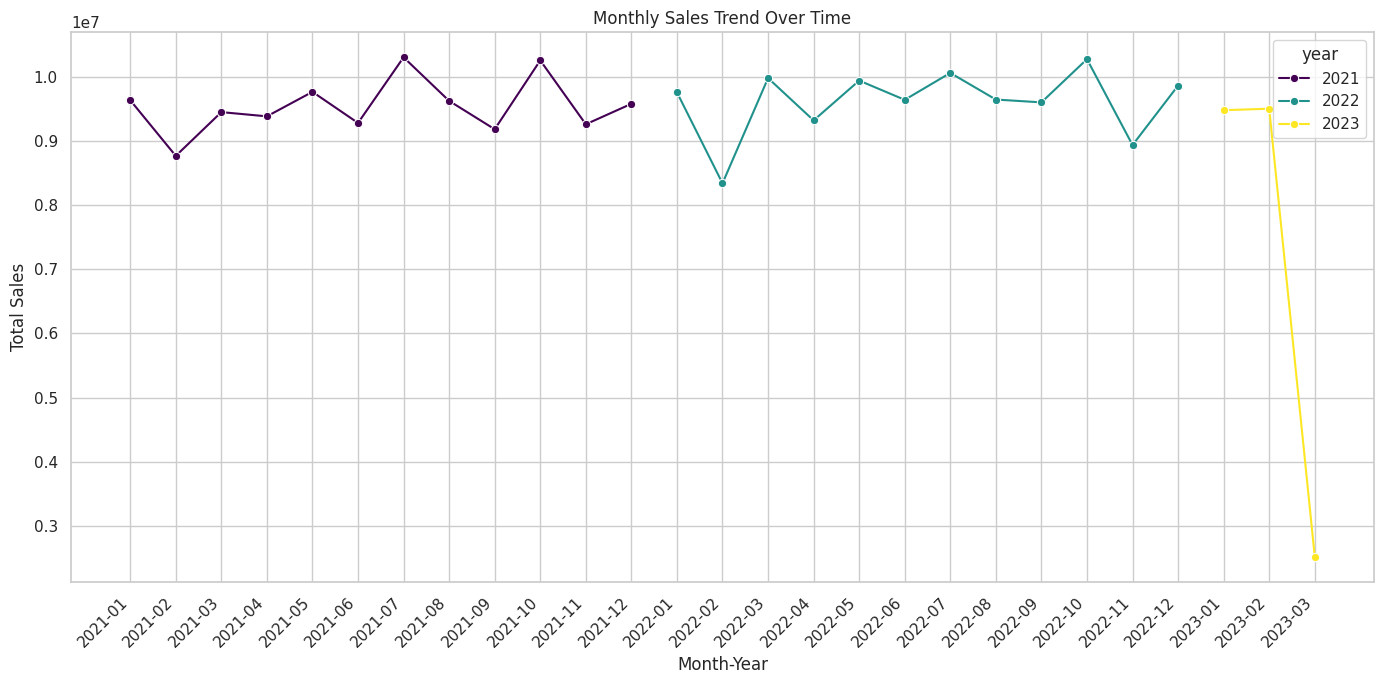

In [32]:
plt.figure(figsize=(14, 7))

# Added int() around year and month to ensure formatting works
x_values = monthly_sales.apply(lambda row: f"{int(row['year'])}-{int(row['month']):02d}", axis=1)

sns.lineplot(
    data=monthly_sales,
    x=x_values,
    y='total_price',
    hue='year',
    marker='o',
    palette='viridis'
)

plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

By integrating Artificial Intelligence into this Exploratory Data Analysis, we can transform static observations into a dynamic, predictive strategy that goes far beyond simple grouping. Machine learning models, such as K-Means Clustering, can refine our RFM analysis by identifying hidden sub-segments within the 88,462 "Other" customers that manual quantiles might miss, while Natural Language Processing (NLP) could eventually be used to analyze customer reviews or category descriptions for sentiment-driven trends. Furthermore, AI-driven Predictive Modeling—using algorithms like Random Forest or XGBoost—allows us to forecast the "Lifetime Value" of a new 18-year-old female shopper at the Mall of Istanbul before she even makes her second purchase. This shift from descriptive statistics (what happened) to prescriptive analytics (what will happen) enables automated, personalized marketing at scale, ensuring that "At-risk" customers receive a discount notification the moment their behavior deviates from their established pattern.